In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [32, 32 ,32],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  RVH421
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
(8887, 20)
(3026, 20)
(8887, 20)
(3026, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.06537568266215045
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.0175 g_loss=-5.1318 | train mmd=0.2870 | test_mmd=1.2539
[CellOT] epoch=50 f_loss=-2.5377 g_loss=-0.8909 | train mmd=0.1996 | test_mmd=0.5366
[CellOT] epoch=100 f_loss=-1.3317 g_loss=0.5558 | train mmd=0.2824 | test_mmd=0.2931
[CellOT] epoch=150 f_loss=-2.0428 g_loss=2.4468 | train mmd=0.2810 | test_mmd=0.2401
[CellOT] epoch=200 f_loss=-2.6850 g_loss=3.2152 | train mmd=0.2258 | test_mmd=0.2015
[CellOT] epoch=250 f_loss=-3.1288 g_loss=4.1186 | train mmd=0.2065 | test_mmd=0.1755
[CellOT] epoch=300 f_loss=-3.0523 g_loss=5.0467 | train mmd=0.1657 | test_mmd=0.1842
[CellOT] epoch=350 f_loss=-3.5171 g_loss=5.6929 | train mmd=0.1490 | test_mmd=0.1590
[CellOT] epoch=400 f_loss=-3.0573 g_loss=5.6139 | train mmd=0.1177 | test_mmd=0.1780
[CellOT] epoch=450 f_loss=-2.8784 g_loss=5.6864 | train mmd=0.1088 | test_mmd=0.1539
[CellOT] epoch=500 f_loss=-1.4331 g_loss=6.3676 | train mmd=0.0661 | test_mmd=0.1805
[CellOT] epoch=550 f_loss=-0.6538 g_loss=6.2812 | train mmd=0.0718

Run 0 metrics: {'mmd2_gamma_median': 0.2046219757327803, 'mmd2_gamma_0.5': 0.304043295711524, 'mmd2_gamma_1.0': 0.18379343400441706, 'wasserstein_distance': 2.278094276959833, 'R2_feature_means': 0.511597677436005}
**************** Run: 1 ****************


...

Run 8 metrics: {'mmd2_gamma_median': 0.20534671089613066, 'mmd2_gamma_0.5': 0.3138657521149091, 'mmd2_gamma_1.0': 0.19148291259913094, 'wasserstein_distance': 2.1422633954022285, 'R2_feature_means': 0.5461918720509329}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-1.0751 g_loss=-6.1619 | train mmd=0.2521 | test_mmd=1.5158
[CellOT] epoch=50 f_loss=-2.1623 g_loss=-1.3496 | train mmd=0.1903 | test_mmd=0.4644
[CellOT] epoch=100 f_loss=-2.1650 g_loss=0.9152 | train mmd=0.3221 | test_mmd=0.2434
[CellOT] epoch=150 f_loss=-2.6296 g_loss=2.2013 | train mmd=0.3155 | test_mmd=0.2326
[CellOT] epoch=200 f_loss=-3.7542 g_loss=3.4385 | train mmd=0.2934 | test_mmd=0.1949
[CellOT] epoch=250 f_loss=-3.9513 g_loss=4.7893 | train mmd=0.2545 | test_mmd=0.1857
[CellOT] epoch=300 f_loss=-3.5157 g_loss=5.7633 | train mmd=0.2345 | test_mmd=0.1772
[CellOT] epoch=350 f_loss=-3.9423 g_loss=6.4655 | train mmd=0.2008 | test_mmd=0.2156
[CellOT] epoch=400 f_loss=-4.3059 g_loss=6.8465 | train mmd=0.1819 | test_mmd=0.1929
[CellOT] epoch=450 f_loss=-3.8805 g_loss=7.7703 | train mmd=0.1622 | test_mmd=0.2510
[CellOT] epoch=500 f_loss=-3.1901 g_loss=8.2434 | train mmd=0.1391 | test_mmd=0.2403
[CellOT] epoch=550 f_loss=-2.1779 g_loss=9.0716 | train mmd=0.1063

Run 9 metrics: {'mmd2_gamma_median': 0.2198113656419418, 'mmd2_gamma_0.5': 0.3201637315605238, 'mmd2_gamma_1.0': 0.18711200684672558, 'wasserstein_distance': 2.2215850754406254, 'R2_feature_means': 0.5009875470873894}
                        mean     std
mmd2_gamma_median     0.2269  0.0270
mmd2_gamma_0.5        0.3202  0.0117
mmd2_gamma_1.0        0.1884  0.0099
wasserstein_distance  2.2953  0.1494
R2_feature_means      0.4890  0.0537


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


NameError: name 'drug' is not defined

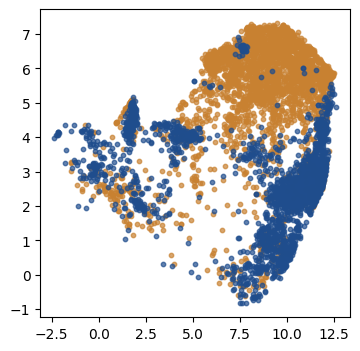

In [5]:
X_pre_COLO858, X_post_COLO858 = prepare_pair_from_mat('COLO858', 'DMSO','24h', 'Vem', '72h')
X_pre_WM902B, X_post_WM902B = prepare_pair_from_mat('WM902B', 'DMSO','24h', 'Vem', '72h')
X_pre_RVH421, X_post_RVH421 = prepare_pair_from_mat('RVH421', 'DMSO','24h', 'Vem', '72h')
X_pre_SKMEL19, X_post_SKMEL19 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', 'Vem', '72h')

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_WM902B, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_WM902B, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_COLO858
Y_te_post = X_post_COLO858

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(6223, 20)
(5690, 20)
(6223, 20)
(5690, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.0690751261506031
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.1663 g_loss=-5.2909 | train mmd=0.1965 | test_mmd=1.4446
[CellOT] epoch=50 f_loss=-2.5350 g_loss=-0.9830 | train mmd=0.1052 | test_mmd=0.3513
[CellOT] epoch=100 f_loss=-1.7877 g_loss=1.0065 | train mmd=0.1583 | test_mmd=0.1352
[CellOT] epoch=150 f_loss=-1.6352 g_loss=2.5520 | train mmd=0.1677 | test_mmd=0.1489
[CellOT] epoch=200 f_loss=-2.2074 g_loss=4.0857 | train mmd=0.1380 | test_mmd=0.1254
[CellOT] epoch=250 f_loss=-1.5634 g_loss=4.5066 | train mmd=0.1203 | test_mmd=0.1300
[CellOT] epoch=300 f_loss=-1.1782 g_loss=5.1757 | train mmd=0.1029 | test_mmd=0.1180
[CellOT] epoch=350 f_loss=-1.4037 g_loss=5.6071 | train mmd=0.0698 | test_mmd=0.1259
[CellOT] epoch=400 f_loss=-0.7334 g_loss=5.7634 | train mmd=0.0788 | test_mmd=0.1238
[CellOT] epoch=450 f_loss=-0.2139 g_loss=6.2973 | train mmd=0.0733 | test_mmd=0.1145
[CellOT] epoch=500 f_loss=0.5888 g_loss=6.4206 | train mmd=0.0374 | test_mmd=0.1211
[CellOT] epoch=550 f_loss=0.1006 g_loss=7.0757 | train mmd=0.0304 |

Run 0 metrics: {'mmd2_gamma_median': 0.08912561013950882, 'mmd2_gamma_0.5': 0.16413281961540072, 'mmd2_gamma_1.0': 0.1302365394309388, 'wasserstein_distance': 1.4498880291413794, 'R2_feature_means': 0.8152062844834286}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=0.6645 g_loss=-5.0801 | train mmd=0.2248 | test_mmd=1.1853
[CellOT] epoch=50 f_loss=-2.7315 g_loss=-0.7798 | train mmd=0.1121 | test_mmd=0.2390
[CellOT] epoch=100 f_loss=-1.4179 g_loss=1.4880 | train mmd=0.2119 | test_mmd=0.1238
[CellOT] epoch=150 f_loss=-1.9445 g_loss=3.0076 | train mmd=0.2518 | test_mmd=0.1211
[CellOT] epoch=200 f_loss=-2.3485 g_loss=4.1466 | train mmd=0.1737 | test_mmd=0.0898
[CellOT] epoch=250 f_loss=-1.7780 g_loss=4.7732 | train mmd=0.1110 | test_mmd=0.1092
[CellOT] epoch=300 f_loss=-0.5146 g_loss=4.7451 | train mmd=0.0805 | test_mmd=0.1135
[CellOT] epoch=350 f_loss=-0.0760 g_loss=5.4782 | train mmd=0.0645 | test_mmd=0.1090
[CellOT] epoch=400 f_loss=-0.4757 g_loss=5.0467 | train mmd=0.0379 | test_mmd=0.1079
[CellOT] epoch=450 f_loss=-0.0247 g_loss=5.7502 | train mmd=0.0304 | test_mmd=0.0968
[CellOT] epoch=500 f_loss=-0.2887 g_loss=6.7049 | train mmd=0.0259 | test_mmd=0.1108
[CellOT] epoch=550 f_loss=0.0872 g_loss=6.9569 | train mmd=0.0332 |

Run 8 metrics: {'mmd2_gamma_median': 0.1373831363246938, 'mmd2_gamma_0.5': 0.2125564255615403, 'mmd2_gamma_1.0': 0.15425969150109758, 'wasserstein_distance': 1.6802574421819934, 'R2_feature_means': 0.6974314500722861}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-0.8976 g_loss=-5.7707 | train mmd=0.1946 | test_mmd=1.4507
[CellOT] epoch=50 f_loss=-2.3175 g_loss=-0.8727 | train mmd=0.1105 | test_mmd=0.3087
[CellOT] epoch=100 f_loss=-1.3526 g_loss=1.0824 | train mmd=0.1341 | test_mmd=0.1643
[CellOT] epoch=150 f_loss=-1.6287 g_loss=2.6872 | train mmd=0.1532 | test_mmd=0.1366
[CellOT] epoch=200 f_loss=-1.7149 g_loss=4.3069 | train mmd=0.1290 | test_mmd=0.1078
[CellOT] epoch=250 f_loss=-1.9385 g_loss=4.3489 | train mmd=0.1118 | test_mmd=0.1095
[CellOT] epoch=300 f_loss=-1.1194 g_loss=4.5700 | train mmd=0.0821 | test_mmd=0.1207
[CellOT] epoch=350 f_loss=-0.9922 g_loss=5.2710 | train mmd=0.0611 | test_mmd=0.1014
[CellOT] epoch=400 f_loss=-0.0552 g_loss=5.7681 | train mmd=0.0451 | test_mmd=0.1074
[CellOT] epoch=450 f_loss=0.4716 g_loss=6.0098 | train mmd=0.0326 | test_mmd=0.1126
[CellOT] epoch=500 f_loss=-0.3557 g_loss=5.8778 | train mmd=0.0252 | test_mmd=0.1116
[CellOT] epoch=550 f_loss=-0.1998 g_loss=7.0887 | train mmd=0.0250 

Run 9 metrics: {'mmd2_gamma_median': 0.10850135129236005, 'mmd2_gamma_0.5': 0.1682214598398002, 'mmd2_gamma_1.0': 0.1258563626693012, 'wasserstein_distance': 1.5977394737657855, 'R2_feature_means': 0.7765130366722877}
                        mean     std
mmd2_gamma_median     0.1197  0.0249
mmd2_gamma_0.5        0.1913  0.0313
mmd2_gamma_1.0        0.1456  0.0314
wasserstein_distance  1.6283  0.1777
R2_feature_means      0.7215  0.0906


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


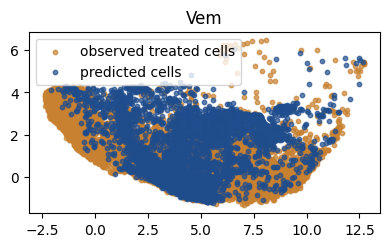

In [6]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_WM902B
Y_te_post = X_post_WM902B

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(11393, 20)
(520, 20)
(11393, 20)
(520, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05893605971644417
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.1546 g_loss=-4.9316 | train mmd=0.2280 | test_mmd=1.1288
[CellOT] epoch=50 f_loss=-2.3639 g_loss=-1.3373 | train mmd=0.1469 | test_mmd=0.1139
[CellOT] epoch=100 f_loss=-1.6463 g_loss=0.7032 | train mmd=0.2383 | test_mmd=0.0553
[CellOT] epoch=150 f_loss=-2.3270 g_loss=2.5501 | train mmd=0.2411 | test_mmd=0.0480
[CellOT] epoch=200 f_loss=-3.4485 g_loss=3.5839 | train mmd=0.2562 | test_mmd=0.0432
[CellOT] epoch=250 f_loss=-3.0942 g_loss=4.8575 | train mmd=0.1880 | test_mmd=0.0507
[CellOT] epoch=300 f_loss=-3.5039 g_loss=5.9602 | train mmd=0.1939 | test_mmd=0.0491
[CellOT] epoch=350 f_loss=-2.6269 g_loss=6.7886 | train mmd=0.1598 | test_mmd=0.0651
[CellOT] epoch=400 f_loss=-3.5504 g_loss=7.9321 | train mmd=0.1353 | test_mmd=0.0708
[CellOT] epoch=450 f_loss=-2.8963 g_loss=7.4610 | train mmd=0.1275 | test_mmd=0.0707
[CellOT] epoch=500 f_loss=-2.6252 g_loss=8.2504 | train mmd=0.1220 | test_mmd=0.0744
[CellOT] epoch=550 f_loss=-0.7366 g_loss=8.2358 | train mmd=0.0946

Run 0 metrics: {'mmd2_gamma_median': 0.09828461876310968, 'mmd2_gamma_0.5': 0.2070721039709303, 'mmd2_gamma_1.0': 0.15524879722154528, 'wasserstein_distance': 1.3584689324449923, 'R2_feature_means': 0.8456496923301827}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=0.7968 g_loss=-4.8555 | train mmd=0.2359 | test_mmd=0.9360
[CellOT] epoch=50 f_loss=-2.4306 g_loss=-0.5957 | train mmd=0.1585 | test_mmd=0.3409
[CellOT] epoch=100 f_loss=-1.8811 g_loss=1.3058 | train mmd=0.3122 | test_mmd=0.0777
[CellOT] epoch=150 f_loss=-2.8272 g_loss=2.8489 | train mmd=0.2900 | test_mmd=0.0541
[CellOT] epoch=200 f_loss=-3.4177 g_loss=4.5906 | train mmd=0.2786 | test_mmd=0.0562
[CellOT] epoch=250 f_loss=-3.4583 g_loss=5.6427 | train mmd=0.2341 | test_mmd=0.0538
[CellOT] epoch=300 f_loss=-4.2030 g_loss=6.1770 | train mmd=0.2249 | test_mmd=0.0421
[CellOT] epoch=350 f_loss=-3.6727 g_loss=7.4982 | train mmd=0.1848 | test_mmd=0.0589
[CellOT] epoch=400 f_loss=-4.5162 g_loss=7.1257 | train mmd=0.1763 | test_mmd=0.0599
[CellOT] epoch=450 f_loss=-2.9860 g_loss=8.8414 | train mmd=0.1428 | test_mmd=0.0666
[CellOT] epoch=500 f_loss=-3.6171 g_loss=9.4556 | train mmd=0.1299 | test_mmd=0.0673
[CellOT] epoch=550 f_loss=-1.9734 g_loss=8.5394 | train mmd=0.1150 

Run 8 metrics: {'mmd2_gamma_median': 0.1024810778115226, 'mmd2_gamma_0.5': 0.2227564254127094, 'mmd2_gamma_1.0': 0.16754191029792329, 'wasserstein_distance': 1.3933697768115016, 'R2_feature_means': 0.847860988678979}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-0.9964 g_loss=-5.8919 | train mmd=0.2113 | test_mmd=1.2393
[CellOT] epoch=50 f_loss=-2.5365 g_loss=-1.0577 | train mmd=0.1492 | test_mmd=0.1820
[CellOT] epoch=100 f_loss=-1.5028 g_loss=1.6414 | train mmd=0.2681 | test_mmd=0.0447
[CellOT] epoch=150 f_loss=-2.3769 g_loss=2.8892 | train mmd=0.2775 | test_mmd=0.0357
[CellOT] epoch=200 f_loss=-2.9426 g_loss=3.3072 | train mmd=0.2145 | test_mmd=0.0487
[CellOT] epoch=250 f_loss=-3.0897 g_loss=3.4846 | train mmd=0.1820 | test_mmd=0.0694
[CellOT] epoch=300 f_loss=-2.7210 g_loss=5.1448 | train mmd=0.1501 | test_mmd=0.0579
[CellOT] epoch=350 f_loss=-2.1038 g_loss=5.8546 | train mmd=0.1353 | test_mmd=0.0875
[CellOT] epoch=400 f_loss=-3.3531 g_loss=6.4746 | train mmd=0.1257 | test_mmd=0.0681
[CellOT] epoch=450 f_loss=-2.2759 g_loss=6.4687 | train mmd=0.1052 | test_mmd=0.0711
[CellOT] epoch=500 f_loss=-1.5028 g_loss=6.7108 | train mmd=0.0661 | test_mmd=0.0804
[CellOT] epoch=550 f_loss=-0.2909 g_loss=6.6498 | train mmd=0.0614

Run 9 metrics: {'mmd2_gamma_median': 0.09236070583367484, 'mmd2_gamma_0.5': 0.22231211627146152, 'mmd2_gamma_1.0': 0.17954653846319993, 'wasserstein_distance': 1.2958298751483999, 'R2_feature_means': 0.8572100590733486}
                        mean     std
mmd2_gamma_median     0.0990  0.0054
mmd2_gamma_0.5        0.2276  0.0131
mmd2_gamma_1.0        0.1784  0.0136
wasserstein_distance  1.3581  0.0366
R2_feature_means      0.8489  0.0100


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


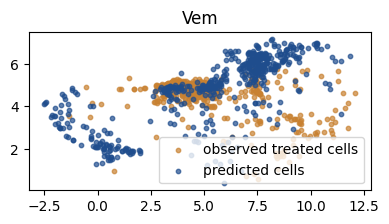

In [7]:


drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_RVH421
Y_te_post = X_post_RVH421

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(9236, 20)
(2677, 20)
(9236, 20)
(2677, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05327606871702425
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.2459 g_loss=-4.8720 | train mmd=0.2569 | test_mmd=0.7831
[CellOT] epoch=50 f_loss=-2.1342 g_loss=-0.3412 | train mmd=0.3210 | test_mmd=0.3002
[CellOT] epoch=100 f_loss=-2.4348 g_loss=1.7372 | train mmd=0.4795 | test_mmd=0.3630
[CellOT] epoch=150 f_loss=-3.5214 g_loss=3.6122 | train mmd=0.4516 | test_mmd=0.3408
[CellOT] epoch=200 f_loss=-4.3790 g_loss=4.8766 | train mmd=0.4459 | test_mmd=0.3334
[CellOT] epoch=250 f_loss=-5.4578 g_loss=6.6891 | train mmd=0.4360 | test_mmd=0.3486
[CellOT] epoch=300 f_loss=-5.8003 g_loss=8.0904 | train mmd=0.4071 | test_mmd=0.3837
[CellOT] epoch=350 f_loss=-6.3917 g_loss=9.4790 | train mmd=0.3585 | test_mmd=0.4073
[CellOT] epoch=400 f_loss=-5.7975 g_loss=10.3197 | train mmd=0.3517 | test_mmd=0.3918
[CellOT] epoch=450 f_loss=-7.9184 g_loss=11.8125 | train mmd=0.3415 | test_mmd=0.3624
[CellOT] epoch=500 f_loss=-6.7538 g_loss=14.1695 | train mmd=0.3282 | test_mmd=0.3777
[CellOT] epoch=550 f_loss=-6.2209 g_loss=14.0771 | train mmd=0.

Run 0 metrics: {'mmd2_gamma_median': 0.19248873320066107, 'mmd2_gamma_0.5': 0.2283108909364993, 'mmd2_gamma_1.0': 0.13106972613820395, 'wasserstein_distance': 2.0731118339426535, 'R2_feature_means': 0.7127407546088289}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=1.0254 g_loss=-4.5952 | train mmd=0.2619 | test_mmd=0.7690
[CellOT] epoch=50 f_loss=-2.8847 g_loss=-0.3257 | train mmd=0.2771 | test_mmd=0.3489
[CellOT] epoch=100 f_loss=-2.1431 g_loss=2.2577 | train mmd=0.5030 | test_mmd=0.3941
[CellOT] epoch=150 f_loss=-3.3974 g_loss=4.2353 | train mmd=0.4762 | test_mmd=0.3369
[CellOT] epoch=200 f_loss=-5.0154 g_loss=5.7536 | train mmd=0.4775 | test_mmd=0.3544
[CellOT] epoch=250 f_loss=-5.9047 g_loss=6.8190 | train mmd=0.4409 | test_mmd=0.3526
[CellOT] epoch=300 f_loss=-6.5059 g_loss=8.7228 | train mmd=0.4308 | test_mmd=0.3681
[CellOT] epoch=350 f_loss=-7.8503 g_loss=10.0146 | train mmd=0.4166 | test_mmd=0.3750
[CellOT] epoch=400 f_loss=-7.5712 g_loss=11.4005 | train mmd=0.3915 | test_mmd=0.3668
[CellOT] epoch=450 f_loss=-7.1084 g_loss=12.7314 | train mmd=0.3595 | test_mmd=0.4192
[CellOT] epoch=500 f_loss=-7.9852 g_loss=14.3450 | train mmd=0.3478 | test_mmd=0.4070
[CellOT] epoch=550 f_loss=-8.2713 g_loss=16.0520 | train mmd=0.

Run 8 metrics: {'mmd2_gamma_median': 0.18743589711255426, 'mmd2_gamma_0.5': 0.24826548475901453, 'mmd2_gamma_1.0': 0.14738998696238514, 'wasserstein_distance': 1.9744041714229177, 'R2_feature_means': 0.7238367587211536}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-0.7296 g_loss=-5.7836 | train mmd=0.2463 | test_mmd=0.8809
[CellOT] epoch=50 f_loss=-2.3160 g_loss=-0.2618 | train mmd=0.3341 | test_mmd=0.4200
[CellOT] epoch=100 f_loss=-2.2098 g_loss=2.3427 | train mmd=0.4668 | test_mmd=0.3835
[CellOT] epoch=150 f_loss=-3.2726 g_loss=3.6541 | train mmd=0.4691 | test_mmd=0.3342
[CellOT] epoch=200 f_loss=-4.2926 g_loss=5.3170 | train mmd=0.4151 | test_mmd=0.3441
[CellOT] epoch=250 f_loss=-5.4413 g_loss=6.8719 | train mmd=0.4377 | test_mmd=0.3530
[CellOT] epoch=300 f_loss=-5.6786 g_loss=8.0000 | train mmd=0.4251 | test_mmd=0.3774
[CellOT] epoch=350 f_loss=-7.2959 g_loss=10.0284 | train mmd=0.3890 | test_mmd=0.3784
[CellOT] epoch=400 f_loss=-7.2250 g_loss=10.9248 | train mmd=0.3591 | test_mmd=0.4117
[CellOT] epoch=450 f_loss=-7.0645 g_loss=12.0686 | train mmd=0.3127 | test_mmd=0.4262
[CellOT] epoch=500 f_loss=-4.9017 g_loss=12.5724 | train mmd=0.2743 | test_mmd=0.4267
[CellOT] epoch=550 f_loss=-6.1329 g_loss=14.2862 | train mmd=0

Run 9 metrics: {'mmd2_gamma_median': 0.23205937509468666, 'mmd2_gamma_0.5': 0.24754436422714612, 'mmd2_gamma_1.0': 0.13978177507946302, 'wasserstein_distance': 2.305379960312297, 'R2_feature_means': 0.6976492956065895}
                        mean     std
mmd2_gamma_median     0.2174  0.0348
mmd2_gamma_0.5        0.2450  0.0150
mmd2_gamma_1.0        0.1405  0.0063
wasserstein_distance  2.2341  0.1878
R2_feature_means      0.6931  0.0350


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


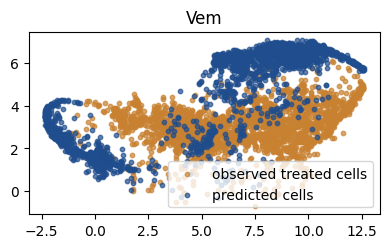

In [8]:



drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_RVH421], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_RVH421], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_SKMEL19
Y_te_post = X_post_SKMEL19


print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)